In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import zipfile

# Path to the zip you uploaded to your main Drive folder
ZIP_PATH = '/content/drive/MyDrive/isl_mega_dataset.zip'
EXTRACT_PATH = '/content/dataset'

if not os.path.exists(EXTRACT_PATH):
    print(f"[INFO] Unzipping {ZIP_PATH}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("[SUCCESS] Dataset extracted.")
else:
    print("[INFO] Dataset already extracted.")


[INFO] Unzipping /content/drive/MyDrive/isl_mega_dataset.zip...
[SUCCESS] Dataset extracted.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import json

RAW_DATA_PATH = os.path.join(EXTRACT_PATH, 'custom_isl_data')
DATA_DIR = RAW_DATA_PATH if os.path.exists(RAW_DATA_PATH) else EXTRACT_PATH

def augment_sequence(seq):
    return seq + np.random.normal(0, 0.015, seq.shape)

sequences, labels = [], []
label_map = {}

words = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print(f"Loading and Augmenting {len(words)} classes...")

for idx, word in enumerate(words):
    label_map[word] = idx
    word_path = os.path.join(DATA_DIR, word)

    for seq_file in os.listdir(word_path):
        if seq_file.endswith('.npy'):
            original = np.load(os.path.join(word_path, seq_file))
            sequences.append(original)
            labels.append(idx)

            for _ in range(4): # 4 augmented versions
                sequences.append(augment_sequence(original))
                labels.append(idx)

X = np.array(sequences)
y = tf.keras.utils.to_categorical(labels).astype(int)

with open('/content/drive/MyDrive/label_map.json', 'w') as f:
    json.dump(label_map, f)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, shuffle=True)

print(f"\n[DONE] Preprocessing Complete!")
print(f"Training Sequences: {X_train.shape[0]}")


Loading and Augmenting 106 classes...

[DONE] Preprocessing Complete!
Training Sequences: 17850


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input

model = Sequential([
    Input(shape=(30, 126)),
    Bidirectional(LSTM(64, return_sequences=True, activation='tanh')),
    Dropout(0.2),
    Bidirectional(LSTM(128, return_sequences=True, activation='tanh')),
    Dropout(0.2),
    Bidirectional(LSTM(64, return_sequences=False, activation='tanh')),
    Dense(128, activation='relu'),
    Dense(len(words), activation='softmax')
])

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        97,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 30, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 106)            │        13,674 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,498 (2.12 MB)

 Trainable params: 555,498 (2.12 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint('/content/drive/MyDrive/isl_model.h5', monitor='val_categorical_accuracy', save_best_only=True, mode='max')
stop_early = EarlyStopping(monitor='val_loss', patience=15)

print("\nStarting Training...")
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, stop_early]
)



Starting Training...
Epoch 1/150
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - categorical_accuracy: 0.5635 - loss: 1.9115

558/558 ━━━━━━━━━━━━━━━━━━━━ 150s 247ms/step - categorical_accuracy: 0.7859 - loss: 0.8713 - val_categorical_accuracy: 0.9778 - val_loss: 0.0917
Epoch 2/150
558/558 ━━━━━━━━━━━━━━━━━━━━ 138s 248ms/step - categorical_accuracy: 0.9585 - loss: 0.1423 - val_categorical_accuracy: 0.9765 - val_loss: 0.0887
Epoch 3/150
558/558 ━━━━━━━━━━━━━━━━━━━━ 140s 251ms/step - categorical_accuracy: 0.9728 - loss: 0.0934 - val_categorical_accuracy: 0.9492 - val_loss: 0.1700
Epoch 4/150
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - categorical_accuracy: 0.9720 - loss: 0.0935

558/558 ━━━━━━━━━━━━━━━━━━━━ 137s 246ms/step - categorical_accuracy: 0.9851 - loss: 0.0504 - val_categorical_accuracy: 0.9984 - val_loss: 0.0045
Epoch 5/150
558/558 ━━━━━━━━━━━━━━━━━━━━ 135s 234ms/step - categorical_accuracy: 0.9738 - loss: 0.0895 - val_categorical_accuracy: 0.9886 - val_loss: 0.0429
Epoch 6/150
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - categorical_accuracy: 0.9859 - loss: 0.0513

558/558 ━━━━━━━━━━━━━━━━━━━━ 143s 236ms/step - categorical_accuracy: 0.9937 - loss: 0.0239 - val_categorical_accuracy: 1.0000 - val_loss: 0.0011
Epoch 7/150
558/558 ━━━━━━━━━━━━━━━━━━━━ 127s 228ms/step - categorical_accuracy: 1.0000 - loss: 8.8278e-04 - val_categorical_accuracy: 1.0000 - val_loss: 5.3799e-04
Epoch 8/150
558/558 ━━━━━━━━━━━━━━━━━━━━ 131s 235ms/step - categorical_accuracy: 1.0000 - loss: 4.6634e-04 - val_categorical_accuracy: 1.0000 - val_loss: 3.0935e-04
Epoch 9/150
558/558 ━━━━━━━━━━━━━━━━━━━━ 140s 250ms/step - categorical_accuracy: 0.9998 - loss: 9.5674e-04 - val_categorical_accuracy: 1.0000 - val_loss: 2.3262e-04
Epoch 10/150
558/558 ━━━━━━━━━━━━━━━━━━━━ 139s 249ms/step - categorical_accuracy: 1.0000 - loss: 2.1529e-04 - val_categorical_accuracy: 1.0000 - val_loss: 1.4009e-04
Epoch 11/150
558/558 ━━━━━━━━━━━━━━━━━━━━ 142s 255ms/step - categorical_accuracy: 1.0000 - loss: 1.3846e-04 - val_categorical_accuracy: 1.0000 - val_loss: 9.4914e-05
Epoch 12/150
558/558 ━━━━━━━

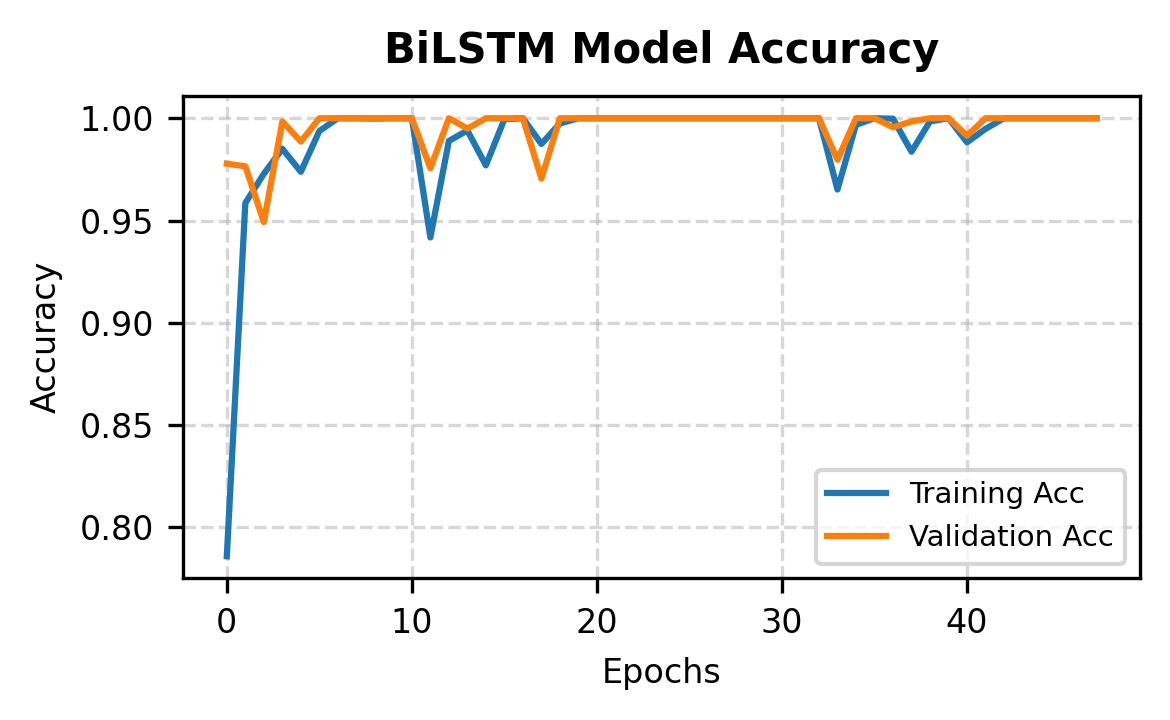

------------------------------


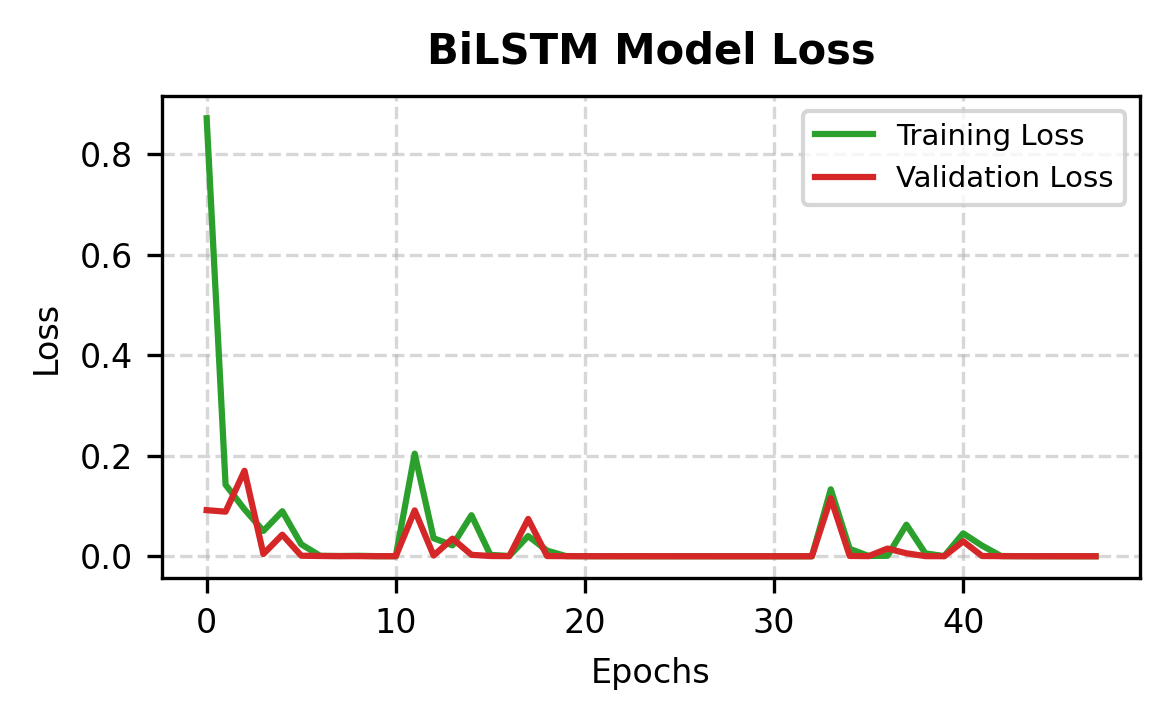


✅ MICRO GRAPHS SAVED! Download them from your Google Drive.


In [ ]:
import matplotlib.pyplot as plt

# 1. Very Compact High-Resolution Accuracy Graph
plt.figure(figsize=(4, 2.5), dpi=300)
plt.plot(history.history['categorical_accuracy'], label='Training Acc', color='#1f77b4', linewidth=1.5)
plt.plot(history.history['val_categorical_accuracy'], label='Validation Acc', color='#ff7f0e', linewidth=1.5)
plt.title('BiLSTM Model Accuracy', fontsize=10, fontweight='bold', pad=8)
plt.xlabel('Epochs', fontsize=8)
plt.ylabel('Accuracy', fontsize=8)
plt.legend(fontsize=7, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/isl_accuracy_graph_micro.png', dpi=300, bbox_inches='tight')
plt.show()

print("-" * 30)

# 2. Very Compact High-Resolution Loss Graph
plt.figure(figsize=(4, 2.5), dpi=300)
plt.plot(history.history['loss'], label='Training Loss', color='#2ca02c', linewidth=1.5)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#d62728', linewidth=1.5)
plt.title('BiLSTM Model Loss', fontsize=10, fontweight='bold', pad=8)
plt.xlabel('Epochs', fontsize=8)
plt.ylabel('Loss', fontsize=8)
plt.legend(fontsize=7, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/isl_loss_graph_micro.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ MICRO GRAPHS SAVED! Download them from your Google Drive.")
